# 인구 지표 EDA

인구 관련 세 지표를 월-행정동 단위로 집계하고 변화율을 확인한다.

- 7. 유동인구 변화율
- 8. 외부유입 변화율
- 9. 경제활동 연령층 proxy 변화율

대용량 parquet는 DuckDB로 필요한 집계 결과만 읽는다.

  유동인구 기본 후보:
  t23, t24

  유동인구 세부 후보:
  t4, t5, t6, t7, t8, t9, t10, t11, t16

  생산인구 기본 후보:
  t23, t24

  생산인구 세부 후보:
  t4, t5, t6, t7, t8, t9, t10, t11, t12, t13, t14, t16, t25, t26, t27

  유입인구 기본 후보:
  t13

  유입인구 세부 후보:
  t12, t14, t25, t26

## 0. 라이브러리와 데이터 경로 설정

필요한 라이브러리를 불러오고, 실행 위치와 관계없이 `data` 폴더 경로를 잡는다.

In [4]:
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

con = duckdb.connect()

cwd = Path.cwd()
DATA_DIR = cwd / "data" if (cwd / "data").exists() else cwd.parent / "data"

t24_path = (DATA_DIR / "t24_2023_2025_all_date_final.parquet").as_posix()
t13_path = (DATA_DIR / "t13_2023_2025_all_final_v2.parquet").as_posix()

t24_path, t13_path

('c:/Users/wlfbs/final_project/data/t24_2023_2025_all_date_final.parquet',
 'c:/Users/wlfbs/final_project/data/t13_2023_2025_all_final_v2.parquet')

## 1. 사용할 파일 확인

인구 EDA에는 `t24`, `t13` 두 파일을 사용한다.

- `t24`: 행정동별 유동/생활인구 집계
- `t13`: 출발지-도착지 기준 외부유입 집계

파일 전체를 읽지 않고 메타데이터만 확인한다.

In [5]:
for name, path in {"t24": t24_path, "t13": t13_path}.items():
    pf = pq.ParquetFile(path)
    print(f"[{name}] rows={pf.metadata.num_rows:,}, columns={len(pf.schema_arrow.names)}")
    print(pf.schema_arrow.names)
    print()

[t24] rows=43,306,619, columns=10
['ETL_YMD', 'ADMI_CD', 'MEGA_NM', 'CTY_NM', 'ADMI_NM', 'SEX_CD', 'AGE_GRP', 'TIME_CD', 'PURPOSE', 'CNT']

[t13] rows=279,996,851, columns=17
['ETL_YMD', 'O_ADMI_CD', 'O_MEGA_NM', 'O_ADMI_NM', 'O_CENTER_X', 'O_CENTER_Y', 'D_ADMI_CD', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT', 'O_CTY_NM', 'D_MEGA_NM', 'D_CTY_NM', 'D_ADMI_NM', 'D_CENTER_X', 'D_CENTER_Y']



## 이번 EDA에서 만든 파생 컬럼 정리

`CNT`를 인구/이동량 규모로 보고 월 단위 합계와 전월 대비 변화율을 만들었다.

핵심은 **규모**와 **최근 변화 방향**을 같이 보는 것이다.

| 파생 컬럼 | 의미 | 생성 기준 | 해석 |
|---|---|---|---|
| `ym` | 기준 연월 | `ETL_YMD`를 `YYYY-MM`으로 변환 | 월 단위 결합 기준 |
| `floating_pop` | 유동인구 규모 | `t24`의 월-행정동별 `CNT` 합계 | 전체 사람 규모 |
| `floating_change_rate` | 유동인구 변화율 | `floating_pop.pct_change()` | 전월 대비 증감률 |
| `external_inflow` | 외부유입 규모 | 성남 밖 → 성남 안 이동의 `CNT` 합계 | 외부 방문 수요 |
| `external_inflow_change_rate` | 외부유입 변화율 | `external_inflow.pct_change()` | 외부 방문 수요 증감률 |
| `working_pop` | 경제활동 연령층 유동인구 proxy | `AGE_GRP` 03~07 코드의 `CNT` 합계 | 정확한 생산가능인구가 아니라 연령대 코드 기반 대체 지표 |
| `working_pop_change_rate` | 경제활동 연령층 proxy 변화율 | `working_pop.pct_change()` | 해당 대체 지표의 전월 대비 증감률 |

### 해석할 때 주의할 점

변화율은 지난달 값이 작으면 과하게 튈 수 있으므로 원 규모 컬럼과 같이 본다.

첫 달 변화율 `NaN`은 비교할 전월이 없기 때문에 정상이다.

## 2. 유동인구 변화율

`t24`의 `CNT`를 월-구-행정동 단위로 합산한다.

일별 변동을 줄이기 위해 월 단위로 보고, 전월 대비 변화율을 계산한다.

`유동인구 변화율 = (이번 달 유동인구 - 지난 달 유동인구) / 지난 달 유동인구`

In [7]:
floating_monthly = con.execute(f"""
    SELECT
        strftime(ETL_YMD, '%Y-%m') AS ym,
        CTY_NM,
        ADMI_NM,
        SUM(CNT) AS floating_pop
    FROM read_parquet('{t24_path}')
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()

floating_monthly["floating_change_rate"] = (
    floating_monthly
    .sort_values("ym")
    .groupby(["CTY_NM", "ADMI_NM"])["floating_pop"]
    .pct_change()
)

floating_monthly.head()

,ym,CTY_NM,ADMI_NM,floating_pop,floating_change_rate
0,2023-01,성남시 분당구,구미1동,902523.46,NaN
1,2023-01,성남시 분당구,구미동,1590973.71,NaN
2,2023-01,성남시 분당구,금곡동,1227167.41,NaN
3,2023-01,성남시 분당구,백현동,1433307.04,NaN
4,2023-01,성남시 분당구,분당동,684549.56,NaN


### 유동인구 추세 그래프

행정동별 값은 너무 많으므로 먼저 구 단위로 합쳐서 전체 흐름을 확인한다. 이 그래프는 성남시 안에서 어느 구의 유동인구 규모가 크고, 월별 방향성이 비슷한지 보는 용도다.

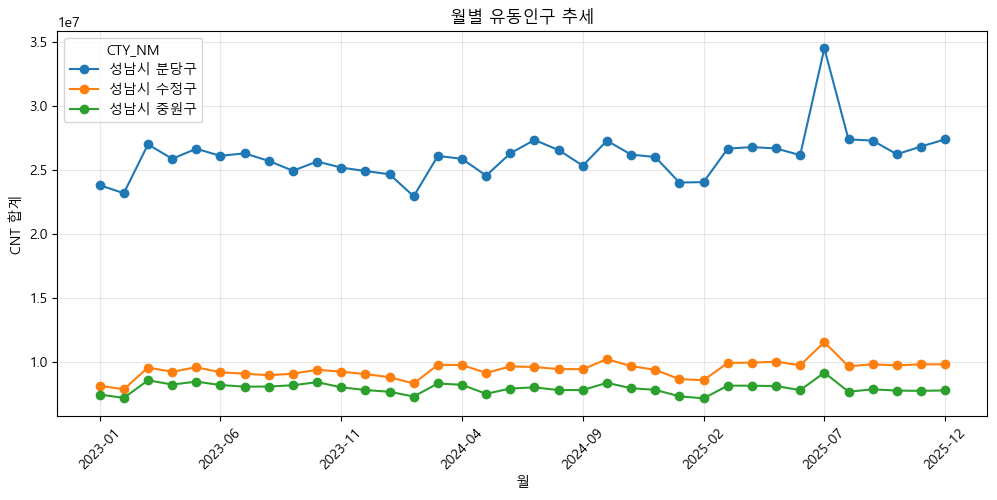

In [8]:
floating_cty = (
    floating_monthly
    .groupby(["ym", "CTY_NM"], as_index=False)["floating_pop"]
    .sum()
)

ax = floating_cty.pivot(index="ym", columns="CTY_NM", values="floating_pop").plot(
    figsize=(12, 5), marker="o"
)
ax.set_title("월별 유동인구 추세")
ax.set_xlabel("월")
ax.set_ylabel("CNT 합계")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### 최근 월 변화율 상위 행정동

최근 월 기준으로 전월 대비 유동인구가 크게 증가한 행정동을 확인한다. 급증 지역은 이후 상권, 매출, 부동산 지표와 연결해서 볼 후보가 된다.

In [9]:
latest_ym = floating_monthly["ym"].max()
floating_monthly.query("ym == @latest_ym")    .sort_values("floating_change_rate", ascending=False)    .head(10)

,ym,CTY_NM,ADMI_NM,floating_pop,floating_change_rate
1753,2025-12,성남시 분당구,백현동,1696060.31,0.096025
1766,2025-12,성남시 분당구,이매2동,277737.56,0.079121
1761,2025-12,성남시 분당구,야탑1동,2037033.84,0.059743
1758,2025-12,성남시 분당구,수내1동,1243483.97,0.053452
1756,2025-12,성남시 분당구,서현1동,3025198.99,0.042647
1778,2025-12,성남시 수정구,시흥동,993159.13,0.041949
1794,2025-12,성남시 중원구,상대원3동,146403.90,0.034941
1752,2025-12,성남시 분당구,금곡동,1470791.82,0.032641
1782,2025-12,성남시 수정구,신흥3동,527834.96,0.028654
1792,2025-12,성남시 중원구,상대원1동,1208670.83,0.026653


## 3. 외부유입 변화율

`t13`에서 성남 밖에서 성남 안으로 들어온 이동만 집계한다.

- 도착지 `D_CTY_NM`: 성남시 포함
- 출발지 `O_CTY_NM`: 성남시 미포함

`외부유입 변화율 = (이번 달 외부유입 - 지난 달 외부유입) / 지난 달 외부유입`

In [10]:
external_inflow_monthly = con.execute(f"""
    SELECT
        strftime(ETL_YMD, '%Y-%m') AS ym,
        D_CTY_NM AS CTY_NM,
        D_ADMI_NM AS ADMI_NM,
        SUM(CNT) AS external_inflow
    FROM read_parquet('{t13_path}')
    WHERE D_CTY_NM LIKE '성남시%'
      AND O_CTY_NM NOT LIKE '성남시%'
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()

external_inflow_monthly["external_inflow_change_rate"] = (
    external_inflow_monthly
    .sort_values("ym")
    .groupby(["CTY_NM", "ADMI_NM"])["external_inflow"]
    .pct_change()
)

external_inflow_monthly.head()

,ym,CTY_NM,ADMI_NM,external_inflow,external_inflow_change_rate
0,2023-01,성남시 분당구,구미1동,378688.61,NaN
1,2023-01,성남시 분당구,구미동,763128.39,NaN
2,2023-01,성남시 분당구,금곡동,480800.65,NaN
3,2023-01,성남시 분당구,백현동,537813.11,NaN
4,2023-01,성남시 분당구,분당동,196878.39,NaN


### 외부유입 추세 그래프

구 단위 외부유입 추세를 보면 성남 내부 유동이 아니라 외부에서 들어오는 수요가 어느 지역으로 집중되는지 확인할 수 있다. 유동인구와 다른 움직임을 보이면 별도 지표로 쓸 가치가 커진다.

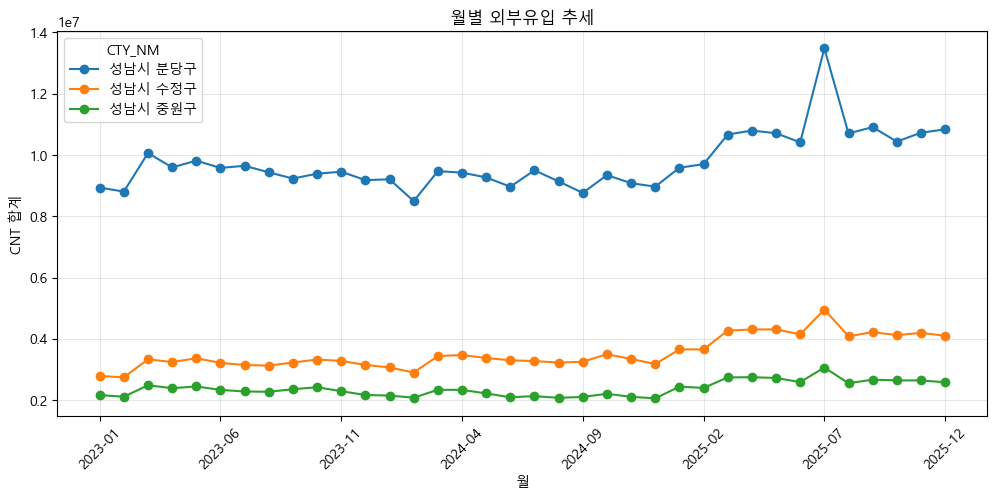

In [11]:
external_inflow_cty = (
    external_inflow_monthly
    .groupby(["ym", "CTY_NM"], as_index=False)["external_inflow"]
    .sum()
)

ax = external_inflow_cty.pivot(index="ym", columns="CTY_NM", values="external_inflow").plot(
    figsize=(12, 5), marker="o"
)
ax.set_title("월별 외부유입 추세")
ax.set_xlabel("월")
ax.set_ylabel("CNT 합계")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### 최근 월 외부유입 변화율 상위 행정동

외부유입 변화율이 큰 지역은 외부 방문 수요가 새로 늘어난 곳일 수 있다. 단, 작은 지역은 분모가 작아 변화율이 크게 튈 수 있으므로 실제 유입 규모도 같이 봐야 한다.

In [12]:
latest_ym = external_inflow_monthly["ym"].max()
external_inflow_monthly.query("ym == @latest_ym")    .sort_values("external_inflow_change_rate", ascending=False)    .head(10)

,ym,CTY_NM,ADMI_NM,external_inflow,external_inflow_change_rate
1753,2025-12,성남시 분당구,백현동,714182.74,0.106083
1758,2025-12,성남시 분당구,수내1동,443038.28,0.080460
1766,2025-12,성남시 분당구,이매2동,79019.08,0.074075
1756,2025-12,성남시 분당구,서현1동,1080394.93,0.026390
1761,2025-12,성남시 분당구,야탑1동,736473.02,0.024150
1752,2025-12,성남시 분당구,금곡동,609843.75,0.019890
1784,2025-12,성남시 수정구,위례동,998719.09,0.017326
1778,2025-12,성남시 수정구,시흥동,558449.49,0.015925
1792,2025-12,성남시 중원구,상대원1동,492637.60,0.013580
1751,2025-12,성남시 분당구,구미동,872804.00,0.012054


## 4. 경제활동 연령층 proxy 변화율

`AGE_GRP` 코드 `03`~`07`의 `CNT` 합계로 경제활동 연령층에 가까운 대체 지표를 계산한다. 단, 연령 코드가 10세 단위라면 이 값은 정확한 생산가능인구(15~64세)가 아니라 proxy로 해석해야 한다.

먼저 `AGE_GRP`별 규모를 확인한다.

In [13]:
age_check = con.execute(f"""
    SELECT
        LPAD(CAST(AGE_GRP AS VARCHAR), 2, '0') AS AGE_GRP,
        SUM(CNT) AS cnt
    FROM read_parquet('{t24_path}')
    GROUP BY 1
    ORDER BY 1
""").df()

age_check

,AGE_GRP,cnt
0,01,1.481234e+07
1,02,1.155793e+08
2,03,2.158881e+08
3,04,2.742221e+08
4,05,2.908573e+08
5,06,3.015389e+08
6,07,2.291467e+08
7,08,9.333486e+07
8,09,2.428199e+07
9,10,1.355076e+06


### 경제활동 연령층 proxy 집계

`working_age_codes`에 포함된 `AGE_GRP` 코드만 남기고 `CNT`를 합산한다. 이후 유동인구와 동일하게 행정동별 전월 대비 변화율을 계산한다.

이 지표는 전체 유동인구 중 특정 연령대 코드(03~07)의 움직임을 따로 보기 위한 것이며, 정확한 생산가능인구로 단정하지 않는다.

In [14]:
working_age_codes = ["03", "04", "05", "06", "07"]

working_pop_monthly = con.execute(f"""
    SELECT
        strftime(ETL_YMD, '%Y-%m') AS ym,
        CTY_NM,
        ADMI_NM,
        SUM(CNT) AS working_pop
    FROM read_parquet('{t24_path}')
    WHERE LPAD(CAST(AGE_GRP AS VARCHAR), 2, '0') IN ({','.join([repr(x) for x in working_age_codes])})
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()

working_pop_monthly["working_pop_change_rate"] = (
    working_pop_monthly
    .sort_values("ym")
    .groupby(["CTY_NM", "ADMI_NM"])["working_pop"]
    .pct_change()
)

working_pop_monthly.head()

,ym,CTY_NM,ADMI_NM,working_pop,working_pop_change_rate
0,2023-01,성남시 분당구,구미1동,769789.30,NaN
1,2023-01,성남시 분당구,구미동,1341357.04,NaN
2,2023-01,성남시 분당구,금곡동,1041526.35,NaN
3,2023-01,성남시 분당구,백현동,1242263.50,NaN
4,2023-01,성남시 분당구,분당동,562728.24,NaN


### 경제활동 연령층 proxy 추세 그래프

구 단위 경제활동 연령층 proxy 추세를 보면 총 유동인구 증가가 특정 연령대 코드의 유동인구 증가와 같이 움직이는지 확인할 수 있다.

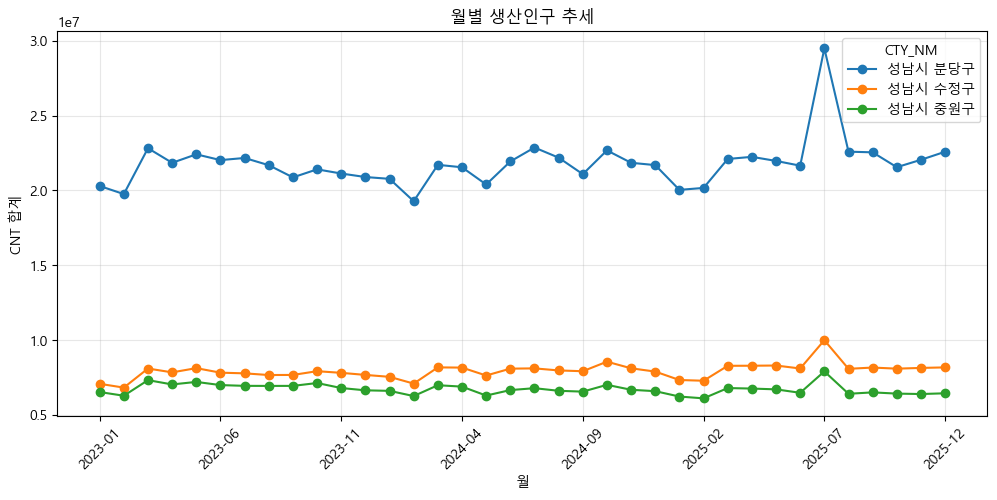

In [15]:
working_pop_cty = (
    working_pop_monthly
    .groupby(["ym", "CTY_NM"], as_index=False)["working_pop"]
    .sum()
)

ax = working_pop_cty.pivot(index="ym", columns="CTY_NM", values="working_pop").plot(
    figsize=(12, 5), marker="o"
)
ax.set_title("월별 경제활동 연령층 proxy 추세")
ax.set_xlabel("월")
ax.set_ylabel("CNT 합계")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

## 5. 세 지표 결합

세 지표를 행정동-월 단위로 합친다. 이렇게 만든 `population_eda`는 이후 매출, 부동산, 거래량 같은 다른 데이터와 `ym`, `CTY_NM`, `ADMI_NM` 기준으로 결합하기 쉽다.

외부유입이 없는 경우는 실제로 0일 수도 있고 매칭 누락일 수도 있으므로, 결측 개수와 값을 함께 확인해야 한다.

In [16]:
population_eda = (
    floating_monthly
    .merge(external_inflow_monthly, on=["ym", "CTY_NM", "ADMI_NM"], how="left")
    .merge(working_pop_monthly, on=["ym", "CTY_NM", "ADMI_NM"], how="left")
)

population_eda["external_inflow"] = population_eda["external_inflow"].fillna(0)

population_eda.head()

,ym,CTY_NM,ADMI_NM,floating_pop,floating_change_rate,external_inflow,external_inflow_change_rate,working_pop,working_pop_change_rate
0,2023-01,성남시 분당구,구미1동,902523.46,NaN,378688.61,NaN,769789.30,NaN
1,2023-01,성남시 분당구,구미동,1590973.71,NaN,763128.39,NaN,1341357.04,NaN
2,2023-01,성남시 분당구,금곡동,1227167.41,NaN,480800.65,NaN,1041526.35,NaN
3,2023-01,성남시 분당구,백현동,1433307.04,NaN,537813.11,NaN,1242263.50,NaN
4,2023-01,성남시 분당구,분당동,684549.56,NaN,196878.39,NaN,562728.24,NaN


## 6. 오류 점검

EDA 전에 기본적인 데이터 품질을 확인한다.

- 행 수가 예상대로 나오는지
- 핵심 지표에 결측치가 많은지
- 무한대 값이 생겼는지
- 변화율 계산 때문에 첫 달에만 결측이 생기는지

첫 달 변화율은 비교 대상인 전월이 없어서 `NaN`이 정상이다.

In [17]:
check_cols = [
    "floating_pop",
    "floating_change_rate",
    "external_inflow",
    "external_inflow_change_rate",
    "working_pop",
    "working_pop_change_rate",
]

quality_check = pd.DataFrame({
    "rows": [len(population_eda)] * len(check_cols),
    "missing": population_eda[check_cols].isna().sum().values,
    "missing_rate": population_eda[check_cols].isna().mean().values,
    "inf_count": [np.isinf(population_eda[c].dropna()).sum() for c in check_cols],
}, index=check_cols)

quality_check

,rows,missing,missing_rate,inf_count
floating_pop,1800,0,0.000000,0
floating_change_rate,1800,50,0.027778,0
external_inflow,1800,0,0.000000,0
external_inflow_change_rate,1800,50,0.027778,0
working_pop,1800,0,0.000000,0
working_pop_change_rate,1800,50,0.027778,0


## 7. 지표가 유의미한지 통계적으로 점검

현재 단계에서는 지표 자체의 품질만 확인한다.

1. 변동성: 값이 거의 고정되어 있으면 EDA 지표로 의미가 작다.
2. 지역 차이: 구/행정동별 차이가 통계적으로 나타나면 공간 지표로 쓸 가치가 있다.
3. 중복성: 세 지표가 서로 거의 같은 값이면 굳이 모두 쓸 필요가 없다.

지역 차이는 permutation test로 간단히 확인한다.

In [18]:
def coefficient_of_variation(s):
    s = pd.Series(s).dropna()
    return s.std() / s.mean() if s.mean() != 0 else np.nan

level_cols = ["floating_pop", "external_inflow", "working_pop"]
change_cols = ["floating_change_rate", "external_inflow_change_rate", "working_pop_change_rate"]

variation_summary = population_eda[level_cols + change_cols].agg(["count", "mean", "std", "min", "median", "max"]).T
variation_summary["cv"] = [coefficient_of_variation(population_eda[c]) for c in variation_summary.index]
variation_summary

,count,mean,std,min,median,max,cv
floating_pop,1800.0,867242.688806,672324.179333,46242.040000,677148.870000,4.511756e+06,0.775243
external_inflow,1800.0,313634.962700,311677.381759,6641.610000,218363.970000,2.269589e+06,0.993758
working_pop,1800.0,728696.192561,585850.932098,38016.970000,550525.590000,4.224524e+06,0.803971
floating_change_rate,1750.0,0.007167,0.090175,-0.300329,-0.008376,8.969757e-01,12.582426
external_inflow_change_rate,1750.0,0.014961,0.114386,-0.313820,-0.005628,1.251507e+00,7.645509
working_pop_change_rate,1750.0,0.005835,0.091981,-0.326667,-0.008378,1.019619e+00,15.764101


### 지역 차이 검정

구별 평균 차이가 우연인지 permutation p-value로 확인한다.

- `p_value < 0.05`: 구별 차이가 통계적으로 뚜렷하다고 볼 수 있음
- `p_value >= 0.05`: 구별 차이가 약하거나, 현재 집계 단위에서는 뚜렷하지 않음

In [19]:
def anova_f_stat(values, groups):
    df = pd.DataFrame({"value": values, "group": groups}).dropna()
    overall_mean = df["value"].mean()
    group_stats = df.groupby("group")["value"].agg(["count", "mean"])
    ss_between = (group_stats["count"] * (group_stats["mean"] - overall_mean) ** 2).sum()
    joined = df.join(group_stats["mean"], on="group", rsuffix="_group")
    ss_within = ((joined["value"] - joined["mean"]) ** 2).sum()
    df_between = len(group_stats) - 1
    df_within = len(df) - len(group_stats)
    return (ss_between / df_between) / (ss_within / df_within)


def permutation_pvalue(values, groups, n_perm=500, seed=42):
    rng = np.random.default_rng(seed)
    clean = pd.DataFrame({"value": values, "group": groups}).dropna()
    observed = anova_f_stat(clean["value"], clean["group"])
    perm_stats = []
    group_values = clean["group"].to_numpy().copy()
    for _ in range(n_perm):
        rng.shuffle(group_values)
        perm_stats.append(anova_f_stat(clean["value"], group_values))
    perm_stats = np.array(perm_stats)
    p_value = (np.sum(perm_stats >= observed) + 1) / (n_perm + 1)
    return observed, p_value

region_test_rows = []
for col in level_cols + change_cols:
    f_stat, p_value = permutation_pvalue(population_eda[col], population_eda["CTY_NM"])
    region_test_rows.append({"indicator": col, "f_stat": f_stat, "p_value": p_value})

region_difference_test = pd.DataFrame(region_test_rows).sort_values("p_value")
region_difference_test

,indicator,f_stat,p_value
0,floating_pop,200.568228,0.001996
1,external_inflow,143.723281,0.001996
2,working_pop,177.571798,0.001996
5,working_pop_change_rate,0.534421,0.606786
3,floating_change_rate,0.415499,0.668663
4,external_inflow_change_rate,0.325509,0.712575


### 지표 중복성 확인

상관계수가 너무 높으면 두 지표가 거의 같은 정보를 담고 있을 수 있다. 특히 `floating_pop`과 `working_pop`은 같은 `t24`에서 나온 지표라 높게 나올 가능성이 있다.

- 0.9 이상: 거의 중복일 가능성이 큼
- 0.7~0.9: 강한 관련성
- 0.3~0.7: 중간 정도 관련성
- 0.3 미만: 서로 다른 정보를 담을 가능성이 큼

In [20]:
correlation_matrix = population_eda[level_cols + change_cols].corr()
correlation_matrix

,floating_pop,external_inflow,working_pop,floating_change_rate,external_inflow_change_rate,working_pop_change_rate
floating_pop,1.000000,0.961077,0.997149,0.061963,-0.006630,0.069198
external_inflow,0.961077,1.000000,0.967974,0.056572,0.006332,0.063504
working_pop,0.997149,0.967974,1.000000,0.063331,-0.003921,0.071470
floating_change_rate,0.061963,0.056572,0.063331,1.000000,0.707145,0.987708
external_inflow_change_rate,-0.006630,0.006332,-0.003921,0.707145,1.000000,0.708851
working_pop_change_rate,0.069198,0.063504,0.071470,0.987708,0.708851,1.000000


### 월별 방향성 확인

각 지표가 시간에 따라 증가/감소하는 경향이 있는지 간단한 선형 추세 기울기를 계산한다. 이 값은 엄밀한 예측 모델이 아니라 EDA용 방향성 체크다.

기울기가 양수면 시간이 지날수록 증가, 음수면 감소 경향으로 해석한다.

In [21]:
trend_df = population_eda.copy()
trend_df["month_index"] = pd.PeriodIndex(trend_df["ym"], freq="M").astype(int)

trend_rows = []
for cty, g in trend_df.groupby("CTY_NM"):
    x = g.groupby("ym")[level_cols].sum().reset_index()
    x["month_index"] = pd.PeriodIndex(x["ym"], freq="M").astype(int)
    for col in level_cols:
        slope = np.polyfit(x["month_index"], x[col], 1)[0]
        trend_rows.append({"CTY_NM": cty, "indicator": col, "monthly_slope": slope})

trend_summary = pd.DataFrame(trend_rows)
trend_summary.pivot(index="CTY_NM", columns="indicator", values="monthly_slope")

indicator,external_inflow,floating_pop,working_pop
CTY_NM,,,
성남시 분당구,52074.275717,75927.771569,48764.181745
성남시 수정구,39904.532380,35308.647958,23925.224938
성남시 중원구,12562.682961,-3418.274282,-10078.554000


## 8. 해석 정리

아래 셀은 앞에서 계산한 통계 결과를 바탕으로 간단한 해석 문장을 자동으로 만든다.

주의할 점은, 여기서의 검증은 지표 자체의 변동성/지역성/중복성을 보는 것이다. 최종적으로 이 지표가 정말 유의미한지는 매출, 거래량, 공시지가 등 목표변수와 결합한 뒤 회귀분석이나 상관분석으로 다시 확인해야 한다.

In [22]:
for _, row in region_difference_test.iterrows():
    verdict = "지역 차이가 뚜렷함" if row["p_value"] < 0.05 else "지역 차이가 뚜렷하지 않음"
    print(f"{row['indicator']}: p={row['p_value']:.4f}, {verdict}")

print("\n상관계수 절댓값 0.9 이상 조합:")
cols = correlation_matrix.columns
found = False
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        corr = correlation_matrix.loc[c1, c2]
        if abs(corr) >= 0.9:
            found = True
            print(f"- {c1} vs {c2}: corr={corr:.3f}")
if not found:
    print("- 없음")

floating_pop: p=0.0020, 지역 차이가 뚜렷함
external_inflow: p=0.0020, 지역 차이가 뚜렷함
working_pop: p=0.0020, 지역 차이가 뚜렷함
working_pop_change_rate: p=0.6068, 지역 차이가 뚜렷하지 않음
floating_change_rate: p=0.6687, 지역 차이가 뚜렷하지 않음
external_inflow_change_rate: p=0.7126, 지역 차이가 뚜렷하지 않음

상관계수 절댓값 0.9 이상 조합:
- floating_pop vs external_inflow: corr=0.961
- floating_pop vs working_pop: corr=0.997
- external_inflow vs working_pop: corr=0.968
- floating_change_rate vs working_pop_change_rate: corr=0.988


| 파생 컬럼 | 의미 | 생성 기준 | 해석 |
|---|---|---|---|
| `ym` | 기준 연월 | `ETL_YMD`를 `YYYY-MM`으로 변환 | 월 단위 결합 기준 |
| `floating_pop` | 유동인구 규모 | `t24`의 월-행정동별 `CNT` 합계 | 전체 사람 규모 |
| `floating_change_rate` | 유동인구 변화율 | `floating_pop.pct_change()` | 전월 대비 증감률 |
| `external_inflow` | 외부유입 규모 | 성남 밖 → 성남 안 이동의 `CNT` 합계 | 외부 방문 수요 |
| `external_inflow_change_rate` | 외부유입 변화율 | `external_inflow.pct_change()` | 외부 방문 수요 증감률 |
| `working_pop` | 경제활동 연령층 유동인구 proxy | `AGE_GRP` 03~07 코드의 `CNT` 합계 | 정확한 생산가능인구가 아니라 연령대 코드 기반 대체 지표 |
| `working_pop_change_rate` | 경제활동 연령층 proxy 변화율 | `working_pop.pct_change()` | 해당 대체 지표의 전월 대비 증감률 |